In [80]:
import pandas as pd

df = pd.read_csv("./dataset/ftax22ptu.csv")

print("Original shape:", df.shape)

# Rename columns to meaningful names
df = df.rename(columns={
    "WGT": "Survey Weight",
    "STATE": "State",
    "KIDS": "Number of Children",
    "KIDSU17": "Children Under 17",
    "KIDSU18": "Children Under 18",
    "KIDSU13": "Children Under 13",
    "SPAGE": "Spouse Age",
    "TUAGE": "Taxpayer Age",
    "FILESTAT": "Filing Status",

    "WSINCOME": "Wage Income",
    "WSINCSP": "Spouse Wage Income",
    "TBUSINC": "Business Income",
    "TBUSINCSP": "Spouse Business Income",
    "INTINC": "Interest Income",
    "DIVINC": "Dividend Income",
    "RENTINC": "Rental Income",
    "UNEMPINC": "Unemployment Income",
    "UNEMPINCSP": "Spouse Unemployment Income",
    "PENINC": "Pension Income",
    "GSSINC": "Social Security Income",
    "AFDCINC": "AFDC Income",
    "OTHINC": "Other Income",
    "STCAPINC": "Short Term Capital Gain",
    "LTCAPINC": "Long Term Capital Gain",

    "AGI": "Adjusted Gross Income",
    "ADJDEDCT": "Adjusted Deductions",
    "TOTITEMDCT": "Total Itemized Deductions",
    "STDDCT": "Standard Deduction",
    "CHCAREXP": "Child Care Expenses",
    "RESTAXM1": "Real Estate Tax",

    "FEDTAXLIAB": "Federal Tax Liability"
})

# Columns that are identifiers / survey metadata / unwanted for prediction
remove_columns = [
    "X5744",
    "X5746",
    "X5823",
    "YY1",
    "Y1",
    "WGT",
    "TAXUNIT",
    "TAXUNITID",
    "YEAR",

    # Tax calculation outputs / leakage
    "PAYROLLIAB",
    "PAYROLLMTR",
    "PAYROLLATR",
    "STTAXLIAB",
    "FEDMTR1",
    "STMTR1",
    "TAGI",
    "TAXINC",
    "CHILDTC",
    "CHILDTCREF",
    "EITC",
    "FEDTAXBC",
    "STBR",
    "FEDITST",
    "AMTFLG",
    "FEDBR",
    "FEDATR",
    "STATR",
    "TOTATR",
    "PINCNZLIAB",
    "NINCPLIAB",
    "NINCNZLIAB"
]

# Remove only columns that still exist
remove_columns = [col for col in remove_columns if col in df.columns]

df = df.drop(columns=remove_columns)

print("Cleaned shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Original shape: (29290, 79)
Cleaned shape: (29290, 49)

Columns:
['Survey Weight', 'State', 'PERSEXP', 'Number of Children', 'Children Under 17', 'Children Under 18', 'Children Under 13', 'LWP', 'Spouse Age', 'Taxpayer Age', 'Filing Status', 'TOTEXPT', 'Wage Income', 'Spouse Wage Income', 'Business Income', 'Spouse Business Income', 'NTAXINC', 'Interest Income', 'Dividend Income', 'Rental Income', 'Unemployment Income', 'Spouse Unemployment Income', 'CHSPALINC', 'AFDC Income', 'Other Income', 'Pension Income', 'Social Security Income', 'NONPROPINC', 'NONTAX', 'RENT', 'Adjusted Gross Income', 'Real Estate Tax', 'Adjusted Deductions', 'TOTINVEX', 'TOTPINEX', 'Total Itemized Deductions', 'TOTEXPTAMT', 'Standard Deduction', 'NONFILER', 'AGEXMP', 'ITEMIZE', 'CITEMIZE', 'Short Term Capital Gain', 'Long Term Capital Gain', 'Child Care Expenses', 'TINCOME', 'TOTXINC', 'Federal Tax Liability', 'fica']


In [81]:
candidate_features = [
    "Taxpayer Age",
    "Spouse Age",
    "Filing Status",
    "Number of Children",
    "Children Under 17",

    "Wage Income",
    "Spouse Wage Income",
    "Business Income",
    "Spouse Business Income",
    "Interest Income",
    "Dividend Income",
    "Rental Income",
    "Unemployment Income",
    "Spouse Unemployment Income",
    "AFDC Income",
    "Other Income",
    "Pension Income",
    "Social Security Income",
    "Long Term Capital Gain",

    "Real Estate Tax",
    "Adjusted Deductions",
    "Total Itemized Deductions",
    "Standard Deduction"
]

target = "Federal Tax Liability"

In [82]:
X = df[candidate_features]
y = df[target]

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [84]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 29290 entries, 0 to 29289
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Taxpayer Age                29290 non-null  int64  
 1   Spouse Age                  29290 non-null  int64  
 2   Filing Status               29290 non-null  int64  
 3   Number of Children          29290 non-null  int64  
 4   Children Under 17           29290 non-null  int64  
 5   Wage Income                 29290 non-null  float64
 6   Spouse Wage Income          29290 non-null  float64
 7   Business Income             29290 non-null  float64
 8   Spouse Business Income      29290 non-null  int64  
 9   Interest Income             29290 non-null  int64  
 10  Dividend Income             29290 non-null  int64  
 11  Rental Income               29290 non-null  float64
 12  Unemployment Income         29290 non-null  int64  
 13  Spouse Unemployment Income  29290 non-null

In [85]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Taxpayer Age,29290.0,51.232025,1.734224e+01,18.0,37.0,52.0,65.000000,9.500000e+01
Spouse Age,29290.0,21.814203,2.818471e+01,0.0,0.0,0.0,50.000000,8.900000e+01
Filing Status,29290.0,1.818914,9.758167e-01,1.0,1.0,2.0,2.000000,5.000000e+00
Number of Children,29290.0,0.483168,9.286433e-01,0.0,0.0,0.0,1.000000,1.000000e+01
Children Under 17,29290.0,0.279652,6.865743e-01,0.0,0.0,0.0,0.000000,5.000000e+00
Wage Income,29290.0,121528.882378,7.427095e+05,0.0,0.0,28000.0,75000.000000,2.788000e+07
Spouse Wage Income,29290.0,10196.489763,4.254077e+04,0.0,0.0,0.0,0.000000,8.846154e+05
Business Income,29290.0,12643.420963,1.277301e+05,-1000000.0,0.0,0.0,0.000000,6.335000e+06
Spouse Business Income,29290.0,3728.994196,7.254686e+04,-800000.0,0.0,0.0,0.000000,6.335000e+06
Interest Income,29290.0,70803.001536,1.480017e+06,0.0,0.0,0.0,5.000000,7.500000e+07


In [86]:
y.describe()

count    2.929000e+04
mean     3.023797e+05
std      2.687336e+06
min     -3.485571e+04
25%     -1.400000e+03
50%      1.656150e+03
75%      2.374748e+04
max      1.269798e+08
Name: Federal Tax Liability, dtype: float64

In [87]:
missing = X.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [88]:
print("Missing target values:", y.isnull().sum())

Missing target values: 0


In [89]:
df = df.drop_duplicates()

In [90]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [91]:
print(X.dtypes)

Taxpayer Age                    int64
Spouse Age                      int64
Filing Status                   int64
Number of Children              int64
Children Under 17               int64
Wage Income                   float64
Spouse Wage Income            float64
Business Income               float64
Spouse Business Income          int64
Interest Income                 int64
Dividend Income                 int64
Rental Income                 float64
Unemployment Income             int64
Spouse Unemployment Income      int64
AFDC Income                     int64
Other Income                    int64
Pension Income                float64
Social Security Income        float64
Long Term Capital Gain        float64
Real Estate Tax                 int64
Adjusted Deductions           float64
Total Itemized Deductions     float64
Standard Deduction              int64
dtype: object


In [92]:
for column in X.columns:
    print(column, ":", X[column].nunique())

Taxpayer Age : 78
Spouse Age : 71
Filing Status : 5
Number of Children : 9
Children Under 17 : 6
Wage Income : 2910
Spouse Wage Income : 1564
Business Income : 793
Spouse Business Income : 392
Interest Income : 389
Dividend Income : 414
Rental Income : 537
Unemployment Income : 139
Spouse Unemployment Income : 79
AFDC Income : 168
Other Income : 122
Pension Income : 1211
Social Security Income : 372
Long Term Capital Gain : 709
Real Estate Tax : 452
Adjusted Deductions : 3859
Total Itemized Deductions : 5869
Standard Deduction : 7


In [93]:
negative_values = X.lt(0).sum()

print(negative_values[negative_values > 0])

Business Income            495
Spouse Business Income     184
Rental Income              793
Other Income               100
Long Term Capital Gain    1109
dtype: int64


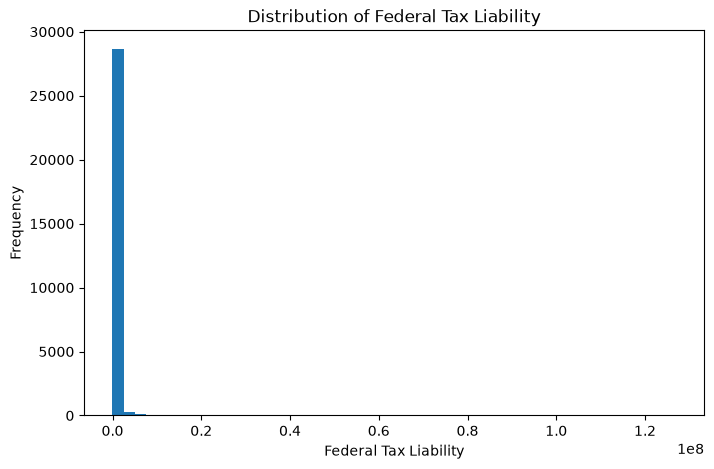

In [94]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=50)

plt.xlabel("Federal Tax Liability")
plt.ylabel("Frequency")
plt.title("Distribution of Federal Tax Liability")

plt.show()

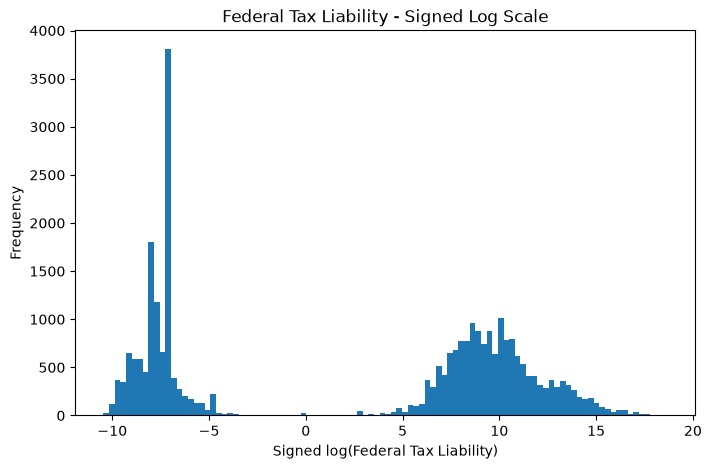

In [95]:
y_signed_log = np.sign(y) * np.log1p(np.abs(y))

plt.figure(figsize=(8, 5))
plt.hist(y_signed_log, bins=100)
plt.xlabel("Signed log(Federal Tax Liability)")
plt.ylabel("Frequency")
plt.title("Federal Tax Liability - Signed Log Scale")
plt.show()

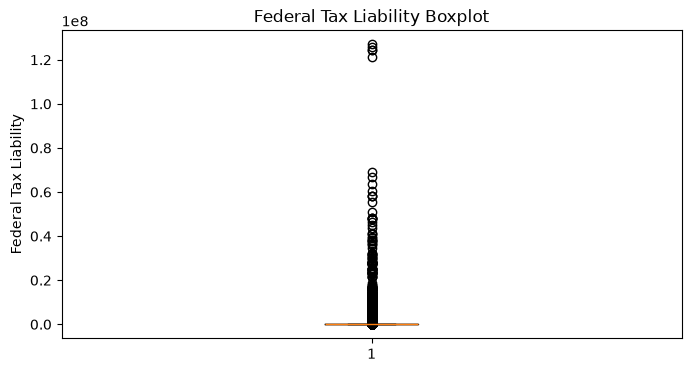

In [96]:
plt.figure(figsize=(8, 4))

plt.boxplot(y)

plt.ylabel("Federal Tax Liability")
plt.title("Federal Tax Liability Boxplot")

plt.show()

In [97]:
skewness = X.select_dtypes(include=np.number).skew()

print(skewness.sort_values(ascending=False))

Other Income                  47.285946
Spouse Business Income        46.364074
Interest Income               42.682065
Total Itemized Deductions     35.160938
Dividend Income               33.304059
Long Term Capital Gain        33.238756
Pension Income                22.687302
Wage Income                   22.002832
Business Income               20.400846
Rental Income                 20.031618
Spouse Unemployment Income    12.335376
Real Estate Tax               11.745295
Unemployment Income           10.625664
Spouse Wage Income             8.685170
AFDC Income                    8.046806
Adjusted Deductions            3.021310
Children Under 17              2.861806
Social Security Income         2.357535
Number of Children             2.333832
Filing Status                  1.204530
Spouse Age                     0.692219
Standard Deduction             0.213271
Taxpayer Age                   0.078720
dtype: float64


In [98]:
correlation = df[candidate_features + [target]].corr()["Federal Tax Liability"]

print(correlation.sort_values(ascending=False))

Federal Tax Liability         1.000000
Long Term Capital Gain        0.850499
Dividend Income               0.667584
Rental Income                 0.522220
Interest Income               0.461393
Real Estate Tax               0.407795
Total Itemized Deductions     0.380097
Wage Income                   0.241445
Spouse Age                    0.125009
Social Security Income        0.113780
Business Income               0.112120
Taxpayer Age                  0.101592
Standard Deduction            0.098989
Pension Income                0.096779
Other Income                  0.023021
Filing Status                 0.015228
Adjusted Deductions           0.010680
Spouse Wage Income           -0.006642
Spouse Business Income       -0.008431
Spouse Unemployment Income   -0.011276
Unemployment Income          -0.017810
Number of Children           -0.024796
Children Under 17            -0.024964
AFDC Income                  -0.027539
Name: Federal Tax Liability, dtype: float64


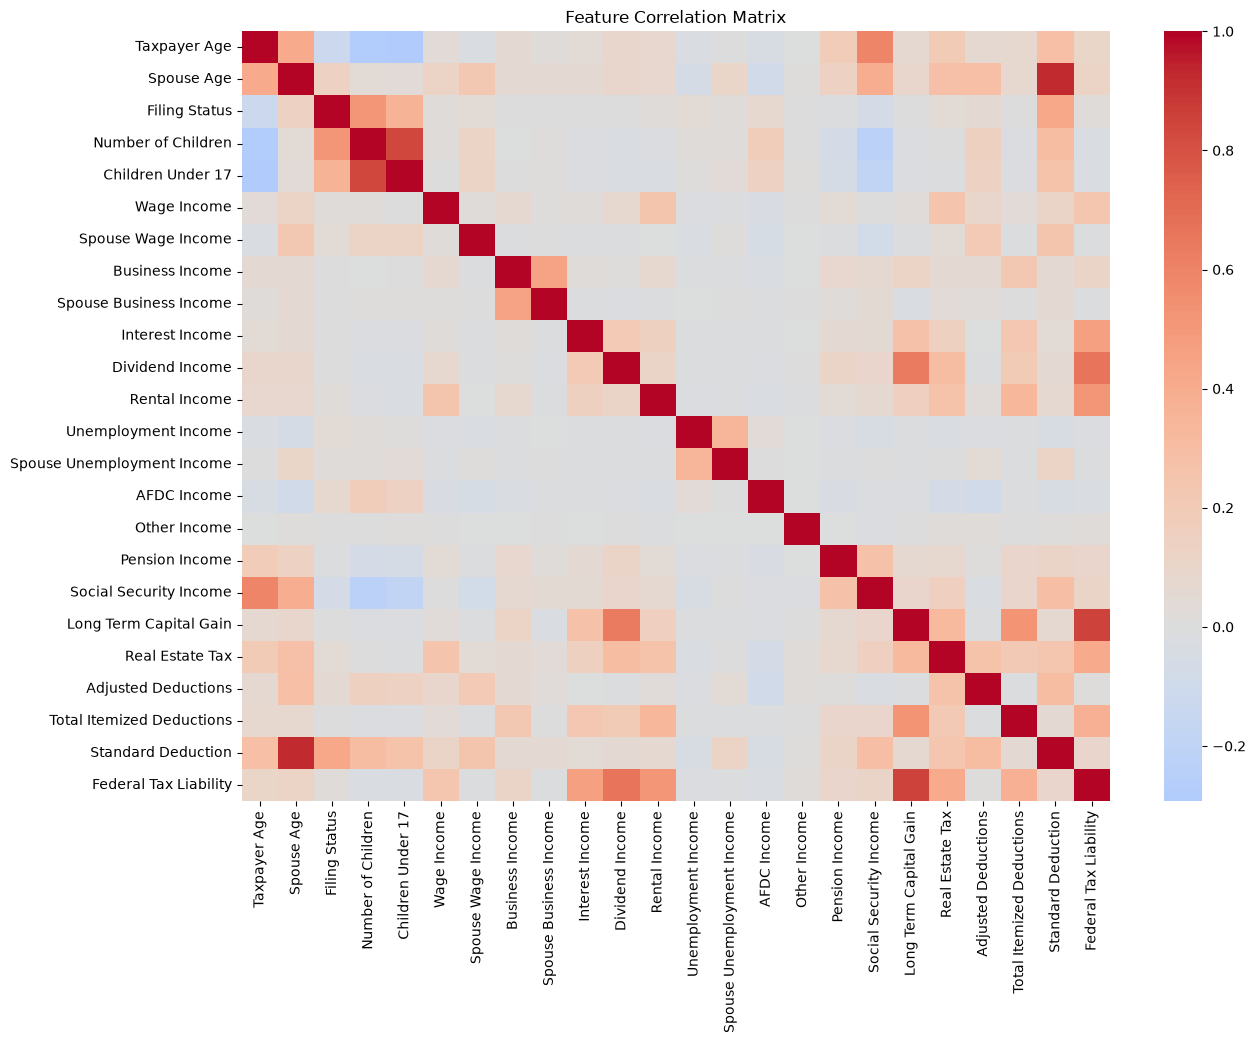

In [99]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df[candidate_features + [target]].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [100]:
print("Infinite values:", np.isinf(X.to_numpy()).sum())
print("Infinite target values:", np.isinf(y.to_numpy()).sum())

Infinite values: 0
Infinite target values: 0


In [101]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 17574
Validation: 5858
Testing: 5858


In [102]:
corr = X_train.corrwith(y_train)

print(corr.sort_values(ascending=False))

Long Term Capital Gain        0.826898
Dividend Income               0.604331
Rental Income                 0.555675
Interest Income               0.459523
Total Itemized Deductions     0.425977
Real Estate Tax               0.400717
Wage Income                   0.265454
Business Income               0.150906
Spouse Age                    0.135996
Pension Income                0.111862
Taxpayer Age                  0.110372
Social Security Income        0.109191
Standard Deduction            0.107825
Other Income                  0.025477
Filing Status                 0.015150
Adjusted Deductions           0.013912
Spouse Business Income        0.001813
Spouse Wage Income           -0.009664
Spouse Unemployment Income   -0.011789
Unemployment Income          -0.018872
Children Under 17            -0.025189
Number of Children           -0.026764
AFDC Income                  -0.030032
dtype: float64


In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [104]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(17574, 23)
(5858, 23)
(5858, 23)


In [105]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("Training")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R2  :", train_r2)

print("\nValidation")
print("MAE :", val_mae)
print("MSE :", val_mse)
print("RMSE:", val_rmse)
print("R2  :", val_r2)

Training
MAE : 38558.629009164004
MSE : 98991335056.79633
RMSE: 314628.88465110183
R2  : 0.9846398887943497

Validation
MAE : 35465.571597829956
MSE : 71907114532.23003
RMSE: 268155.01959170937
R2  : 0.9916158217549246


In [107]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

print(coefficients.sort_values(
    "Abs_Coefficient",
    ascending=False
))

                       Feature   Coefficient  Abs_Coefficient
18      Long Term Capital Gain  1.989812e+06     1.989812e+06
11               Rental Income  1.100039e+06     1.100039e+06
21   Total Itemized Deductions -7.647028e+05     7.647028e+05
9              Interest Income  5.823937e+05     5.823937e+05
10             Dividend Income  3.147842e+05     3.147842e+05
5                  Wage Income  2.991093e+05     2.991093e+05
7              Business Income  1.048382e+05     1.048382e+05
15                Other Income  6.354046e+04     6.354046e+04
16              Pension Income  2.916892e+04     2.916892e+04
19             Real Estate Tax  2.740067e+04     2.740067e+04
17      Social Security Income  2.155482e+04     2.155482e+04
6           Spouse Wage Income  1.466098e+04     1.466098e+04
1                   Spouse Age -8.185255e+03     8.185255e+03
22          Standard Deduction -7.879395e+03     7.879395e+03
20         Adjusted Deductions -5.940531e+03     5.940531e+03
3       

In [108]:
corr_matrix = X_train.corr()

print(corr_matrix)

                            Taxpayer Age  Spouse Age  Filing Status  \
Taxpayer Age                    1.000000    0.413143      -0.117969   
Spouse Age                      0.413143    1.000000       0.138397   
Filing Status                  -0.117969    0.138397       1.000000   
Number of Children             -0.273258    0.046558       0.518775   
Children Under 17              -0.280201    0.042873       0.361584   
Wage Income                     0.043213    0.128713       0.022967   
Spouse Wage Income             -0.021841    0.220709       0.043211   
Business Income                 0.065664    0.066927       0.001904   
Spouse Business Income          0.026809    0.065040       0.009347   
Interest Income                 0.052146    0.065788       0.009410   
Dividend Income                 0.092920    0.089007       0.002835   
Rental Income                   0.088140    0.095731       0.014986   
Unemployment Income            -0.028548   -0.054973       0.046931   
Spouse

In [109]:
corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(15))

Spouse Age              Standard Deduction            0.921006
Number of Children      Children Under 17             0.837640
Long Term Capital Gain  Total Itemized Deductions     0.599886
Taxpayer Age            Social Security Income        0.595515
Dividend Income         Long Term Capital Gain        0.529232
Filing Status           Number of Children            0.518775
Business Income         Spouse Business Income        0.514558
Filing Status           Standard Deduction            0.430280
Taxpayer Age            Spouse Age                    0.413143
Spouse Age              Social Security Income        0.399205
Rental Income           Total Itemized Deductions     0.374026
Filing Status           Children Under 17             0.361584
Unemployment Income     Spouse Unemployment Income    0.347030
Number of Children      Standard Deduction            0.306720
Adjusted Deductions     Standard Deduction            0.305331
dtype: float64


In [111]:
import numpy as np

X_train_gd = X_train_scaled
X_val_gd = X_val_scaled

y_train_gd = y_train.to_numpy()
y_val_gd = y_val.to_numpy()

weights = np.zeros(X_train_gd.shape[1])
bias = 0

learning_rate = 0.01
epochs = 1000

In [112]:
n = len(X_train_gd)

for epoch in range(epochs):

    y_pred = X_train_gd @ weights + bias

    error = y_pred - y_train_gd

    dw = (2 / n) * (X_train_gd.T @ error)
    db = (2 / n) * np.sum(error)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [113]:
y_train_pred = X_train_gd @ weights + bias
y_val_pred = X_val_gd @ weights + bias

In [114]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("Training")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R2  :", train_r2)

print("\nValidation")
print("MAE :", val_mae)
print("MSE :", val_mse)
print("RMSE:", val_rmse)
print("R2  :", val_r2)

Training
MAE : 38560.88835086561
MSE : 99014132176.52579
RMSE: 314665.11115235795
R2  : 0.98463635145147

Validation
MAE : 35342.94396161879
MSE : 71833058424.0627
RMSE: 268016.89951206936
R2  : 0.9916244565001101


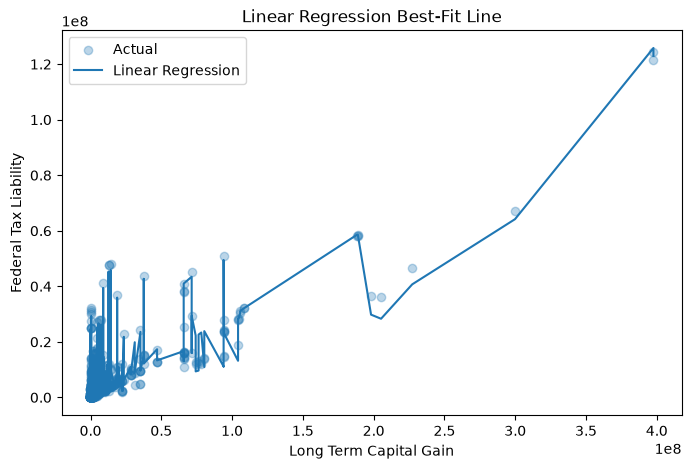

In [115]:
import matplotlib.pyplot as plt

x = X_train["Long Term Capital Gain"].values
y = y_train.values
y_pred = y_train_pred

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.3, label="Actual")

sort_idx = np.argsort(x)

plt.plot(
    x[sort_idx],
    y_pred[sort_idx],
    label="Linear Regression"
)

plt.xlabel("Long Term Capital Gain")
plt.ylabel("Federal Tax Liability")
plt.title("Linear Regression Best-Fit Line")
plt.legend()

plt.show()

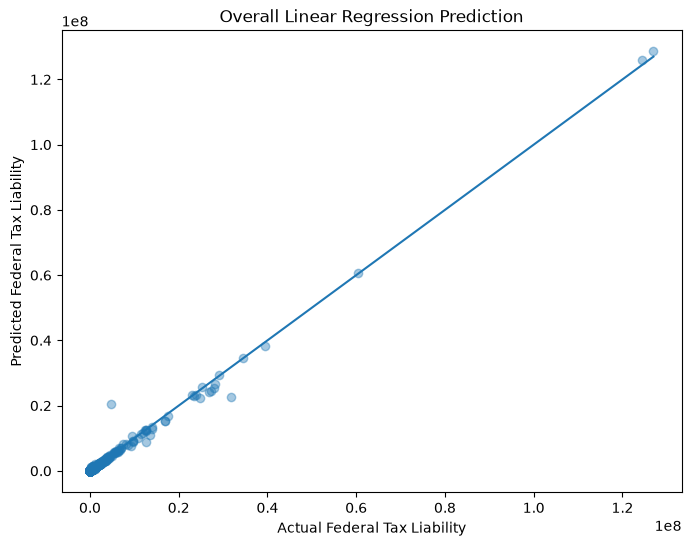

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred, alpha=0.4)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)

plt.xlabel("Actual Federal Tax Liability")
plt.ylabel("Predicted Federal Tax Liability")
plt.title("Overall Linear Regression Prediction")

plt.show()

In [117]:
selected_features = [
    "Long Term Capital Gain",
    "Rental Income",
    "Total Itemized Deductions",
    "Interest Income",
    "Dividend Income",
    "Real Estate Tax",
    "Wage Income",
    "Business Income",
    "Spouse Age",
    "Pension Income"
]

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

In [118]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [119]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("MSE :", mean_squared_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2  :", r2_score(y_train, y_train_pred))

print("\nValidation")
print("MAE :", mean_absolute_error(y_val, y_val_pred))
print("MSE :", mean_squared_error(y_val, y_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("R2  :", r2_score(y_val, y_val_pred))

Training
MAE : 40344.11129135046
MSE : 103430937816.61775
RMSE: 321606.8062349081
R2  : 0.9839510124188503

Validation
MAE : 36627.10578104497
MSE : 75537996843.93684
RMSE: 274841.766920417
R2  : 0.9911924705373675


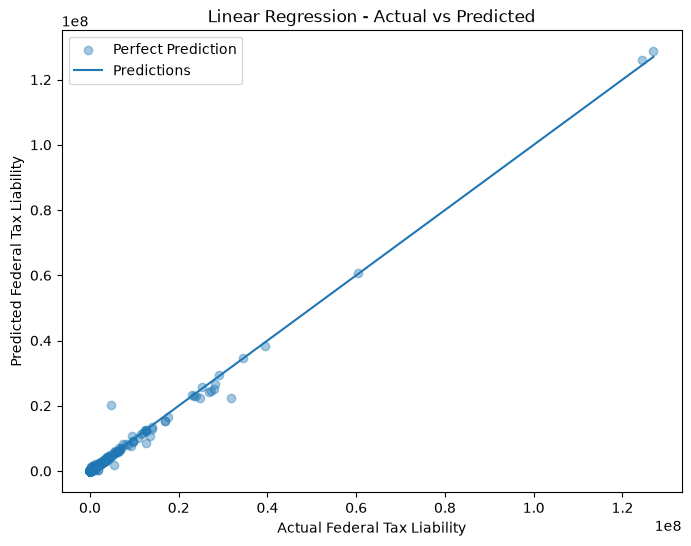

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred, alpha=0.4)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)

plt.xlabel("Actual Federal Tax Liability")
plt.ylabel("Predicted Federal Tax Liability")
plt.title("Linear Regression - Actual vs Predicted")
plt.legend(["Perfect Prediction", "Predictions"])

plt.show()

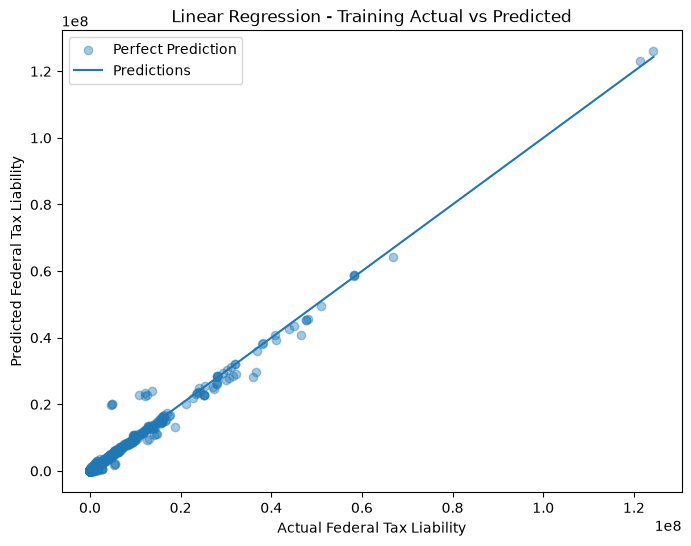

In [122]:
plt.figure(figsize=(8, 6))

plt.scatter(y_train, y_train_pred, alpha=0.4)

plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()]
)

plt.xlabel("Actual Federal Tax Liability")
plt.ylabel("Predicted Federal Tax Liability")
plt.title("Linear Regression - Training Actual vs Predicted")
plt.legend(["Perfect Prediction", "Predictions"])

plt.show()

In [123]:
new_data = [[
    50000,
    10000,
    15000,
    3000,
    5000,
    8000,
    60000,
    10000,
    45,
    12000
]]

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted Federal Tax Liability:", prediction[0])

Predicted Federal Tax Liability: 31698.641095198516


c:\Users\ads2609025\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import streamlit as st
import numpy as np

st.title("Federal Tax Liability Prediction")

st.write("Enter taxpayer information to predict Federal Tax Liability.")

long_term_capital_gain = st.number_input(
    "Long Term Capital Gain", min_value=0.0
)

rental_income = st.number_input(
    "Rental Income", min_value=0.0
)

total_itemized_deductions = st.number_input(
    "Total Itemized Deductions", min_value=0.0
)

interest_income = st.number_input(
    "Interest Income", min_value=0.0
)

dividend_income = st.number_input(
    "Dividend Income", min_value=0.0
)

real_estate_tax = st.number_input(
    "Real Estate Tax", min_value=0.0
)

wage_income = st.number_input(
    "Wage Income", min_value=0.0
)

business_income = st.number_input(
    "Business Income", min_value=0.0
)

spouse_age = st.number_input(
    "Spouse Age", min_value=0, max_value=120
)

pension_income = st.number_input(
    "Pension Income", min_value=0.0
)

if st.button("Predict Tax Liability"):

    new_data = np.array([[
        long_term_capital_gain,
        rental_income,
        total_itemized_deductions,
        interest_income,
        dividend_income,
        real_estate_tax,
        wage_income,
        business_income,
        spouse_age,
        pension_income
    ]])

    new_data_scaled = scaler.transform(new_data)

    prediction = model.predict(new_data_scaled)

    st.success(
        f"Predicted Federal Tax Liability: ${prediction[0]:,.2f}"
    )

In [127]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']